In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from math import log, sqrt, exp

## Нафикова Лиана

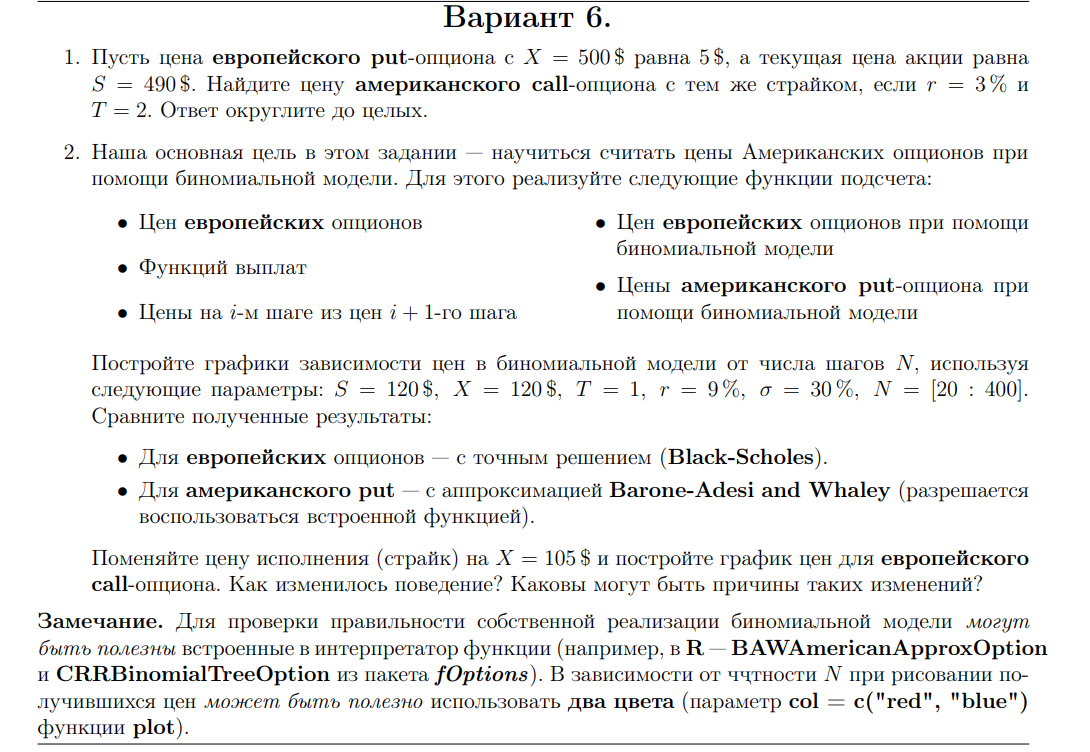

### Задание 1

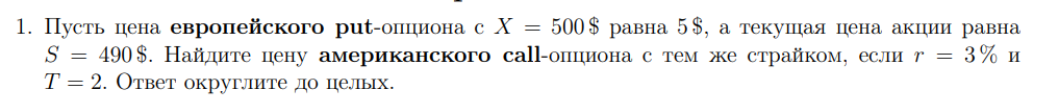

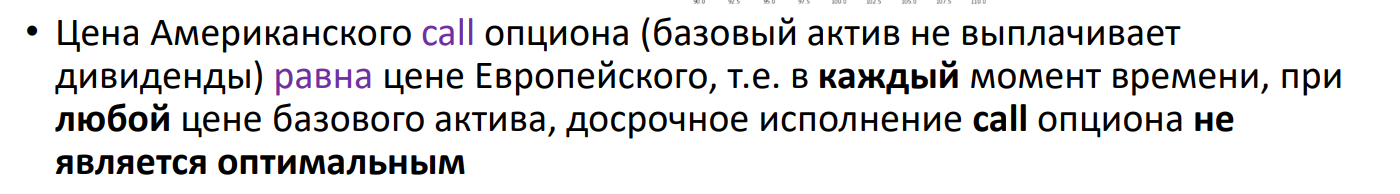

*Дано:*
    
* Страйк опциона: $ X = 500 \$ $

* Цена европейского put-опциона: $ P_{евр} = 5  \$ $

* Текущая цена акции: $ S = 490 \$ $

* Безрисковая ставка: $ r = 3\% = 0.03 $

* Время до экспирации: $ T = 2$  года 

**Решение**

Найдем цену европейского call-опциона ($C_{евр}$) с помощью паритета put-call:

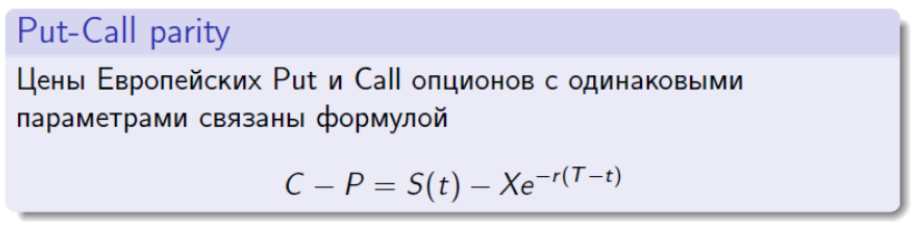
$$
C_{евр} + X e^{-rT} = P_{евр} + S
$$
$$
C_{\text{евр}} = P_{\text{евр}} + S - X e^{-rT}
$$
Подставим значения:
$$
C_{евр} = 5 + 490 - 500 e^{-0.03 \times 2}
$$
$$
C_{евр} = 495 - 500 e^{-0.06}
$$
$$
e^{-0.06} \approx 0.94176
$$
$$
C_{евр} = 495 - 500 \times 0.94176 = 495 - 470.88 = 24.12 \ \$
$$

$$
C_{\text{амер}} = C_{\text{евр}} = 24.12 \ \$
$$
**Ответ:** 
$
C_{\text{амер}} \approx 24 \ \$
$



### Задание 2

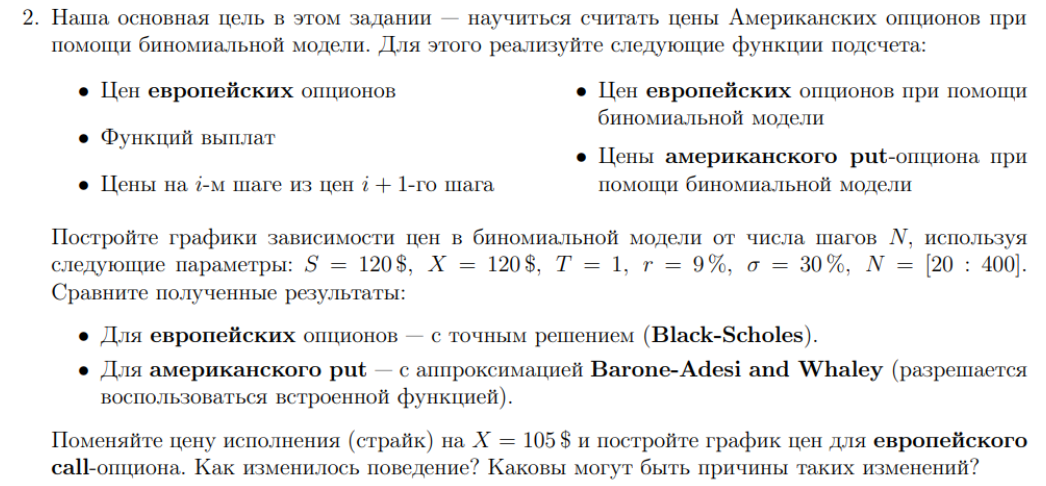

In [2]:
S = 120
X = 120
T = 1
r = 0.09
sigma = 0.3
N_range = range(20, 401)

In [3]:
def black_scholes_call(S, X, T, r, sigma):
    d1 = (np.log(S / X) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - X * np.exp(-r * T) * norm.cdf(d2)

def black_scholes_put(S, X, T, r, sigma):
    d1 = (np.log(S / X) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return X * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

In [4]:
def european_option_payoff(S, X, option_type):
    """
    Функция выплат для европейских опционов
    S: текущая цена акции
    K: страйк цена опциона
    option_type: 'call' или 'put'
    """
    if option_type == 'call':
        return max(S - X, 0)
    
    if option_type == 'put':
        return max(X - S, 0)

In [5]:
S_range = np.arange(50, 150, 1)
call_prices = [black_scholes_call(s, X, T, r, sigma) for s in S_range]
put_prices = [black_scholes_put(s, X, T, r, sigma) for s in S_range]
call_payoffs = [european_option_payoff(s, X, 'call') for s in S_range]
put_payoffs = [european_option_payoff(s, X, 'put') for s in S_range]

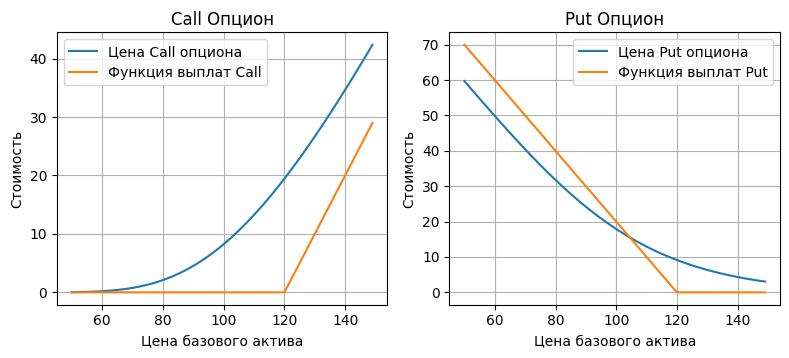

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4)) 

axs[0].plot(S_range, call_prices, label='Цена Call опциона')
axs[0].plot(S_range, call_payoffs, label='Функция выплат Call')
axs[0].set_xlabel('Цена базового актива')
axs[0].set_ylabel('Стоимость')
axs[0].set_title('Call Опцион')
axs[0].legend()
axs[0].grid(True)

axs[1].plot(S_range, put_prices, label='Цена Put опциона')
axs[1].plot(S_range, put_payoffs, label='Функция выплат Put')
axs[1].set_xlabel('Цена базового актива')
axs[1].set_ylabel('Стоимость')
axs[1].set_title('Put Опцион')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])  
plt.show()

In [7]:
def binomial_step_price(up_price, down_price, p, r, dt):
    """
    Расчет цены на i-м шаге из цен i+1-го шага
    up_price: цена при движении вверх
    down_price: цена при движении вниз
    p: риск-нейтральная вероятность движения вверх
    r: безрисковая процентная ставка
    dt: длина шага по времени
    """
    return np.exp(-r * dt) * (p * up_price + (1 - p) * down_price)

In [13]:
def binomial_tree_options(S, X, T, r, sigma, N, option_type='put', american=False):
    """
    Вычисляет цены активов и значения опционов (европейских и американских) на каждом узле биномиального дерева.

    Args:
        S: Начальная цена актива.
        X: Цена исполнения опциона.
        T: Время до истечения опциона.
        r: Безрисковая процентная ставка.
        sigma: Волатильность актива.
        N: Количество шагов в дереве.
        option_type: Тип опциона ('call' или 'put').
        american: True, если опцион американский, False - если европейский.

    Returns:
        tuple: Кортеж из двух numpy.ndarray: матрица цен активов и матрица значений опционов.
    """
    dt = T / N
    u = exp(sigma * sqrt(dt))
    d = 1 / u
    p = (exp(r * dt) - d) / (u - d)
    discount = exp(-r * dt)

    prices = np.zeros((N + 1, N + 1))
    option_values = np.zeros((N + 1, N + 1))

    # Цены активов
    for i in range(N + 1):
        for j in range(i + 1):
            prices[i, j] = S * (u**(i - j)) * (d**j)

    # Значения опционов (обратный проход по дереву)
    for j in range(N + 1):
        if option_type == 'put':
            option_values[N, j] = max(0, X - prices[N, j])  # Выплата put 
        elif option_type == 'call':
            option_values[N, j] = max(0, prices[N, j] - X) #Выплата call 

    for i in range(N - 1, -1, -1):
        for j in range(i + 1):
            if american:
                if option_type == 'put':
                    option_values[i, j] = max(discount * (p * option_values[i + 1, j] + (1 - p) * option_values[i + 1, j + 1]), X - prices[i, j])
                elif option_type == 'call':
                    option_values[i, j] = max(discount * (p * option_values[i + 1, j] + (1 - p) * option_values[i + 1, j + 1]), prices[i, j] - X)
            else:
                option_values[i, j] = discount * (p * option_values[i + 1, j] + (1 - p) * option_values[i + 1, j + 1])

    return prices, option_values

In [29]:
def plot_binomial_tree(prices, option_values, T, r, N, option_type, american, asset_name="Актива", option_name="Опциона"):
    """Строит два отдельных графика: для цены актива и для цены опциона."""
    dt = T / N
    fig, axes = plt.subplots(2, 1, figsize=(12, 12)) # Создаем 2 подграфика


    # График цен актива
    ax = axes[0] # Выбираем первый подграфик
    ax.set_title(f"Биномиальное дерево цены {asset_name} ({option_type}-опцион, {'Американский' if american else 'Европейский'}, N={N}, T={T}, r={r})")
    ax.set_xlabel("Шаги времени")
    ax.set_ylabel("Цена")

    x_coords = np.zeros((N + 1, N + 1))
    y_coords = np.zeros((N + 1, N + 1))

    for i in range(N + 1):
        for j in range(i + 1):
            x_coords[i, j] = i * dt
            y_coords[i, j] = prices[i, j]

    for i in range(N + 1):
        for j in range(i + 1):
            ax.plot(x_coords[i, j], y_coords[i, j], 'o', markersize=6, color='steelblue')
            ax.text(x_coords[i, j], y_coords[i, j], f'S={prices[i, j]:.2f}', ha='center', va='bottom', fontsize=12)

    for i in range(N):
        for j in range(i + 1):
            ax.plot([x_coords[i, j], x_coords[i + 1, j]], [y_coords[i, j], y_coords[i + 1, j]], '-', color='steelblue', linewidth=1)
            ax.plot([x_coords[i, j], x_coords[i + 1, j + 1]], [y_coords[i, j], y_coords[i + 1, j + 1]], '-', color='steelblue', linewidth=1)

    ax.grid(True)
    # График цен опциона
    ax = axes[1] # Выбираем второй подграфик
    ax.set_title(f"Биномиальное дерево цены {option_name} ({option_type}-опцион, {'Американский' if american else 'Европейский'}, N={N}, T={T}, r={r})")
    ax.set_xlabel("Шаги времени")
    ax.set_ylabel("Цена")

    y_coords = np.zeros((N + 1, N + 1))

    for i in range(N + 1):
        for j in range(i + 1):
            y_coords[i, j] = option_values[i, j]

    for i in range(N + 1):
        for j in range(i + 1):
            ax.plot(x_coords[i, j], y_coords[i, j], 'o', markersize=6, color='crimson')
            ax.text(x_coords[i, j], y_coords[i, j], f'V={option_values[i, j]:.2f}', ha='center', va='top', fontsize=12)

    for i in range(N):
        for j in range(i + 1):
            ax.plot([x_coords[i, j], x_coords[i + 1, j]], [y_coords[i, j], y_coords[i + 1, j]], '-', color='crimson', linewidth=1)
            ax.plot([x_coords[i, j], x_coords[i + 1, j + 1]], [y_coords[i, j], y_coords[i + 1, j + 1]], '-', color='crimson', linewidth=1)

    ax.grid(True)
    ax.set_xticks(np.arange(0, T + dt, dt))
    ax.set_xticklabels([f't + {i * dt:.2f}' for i in range(N + 1)])
    plt.tight_layout() #Улучшает расположение подписей
    plt.show()


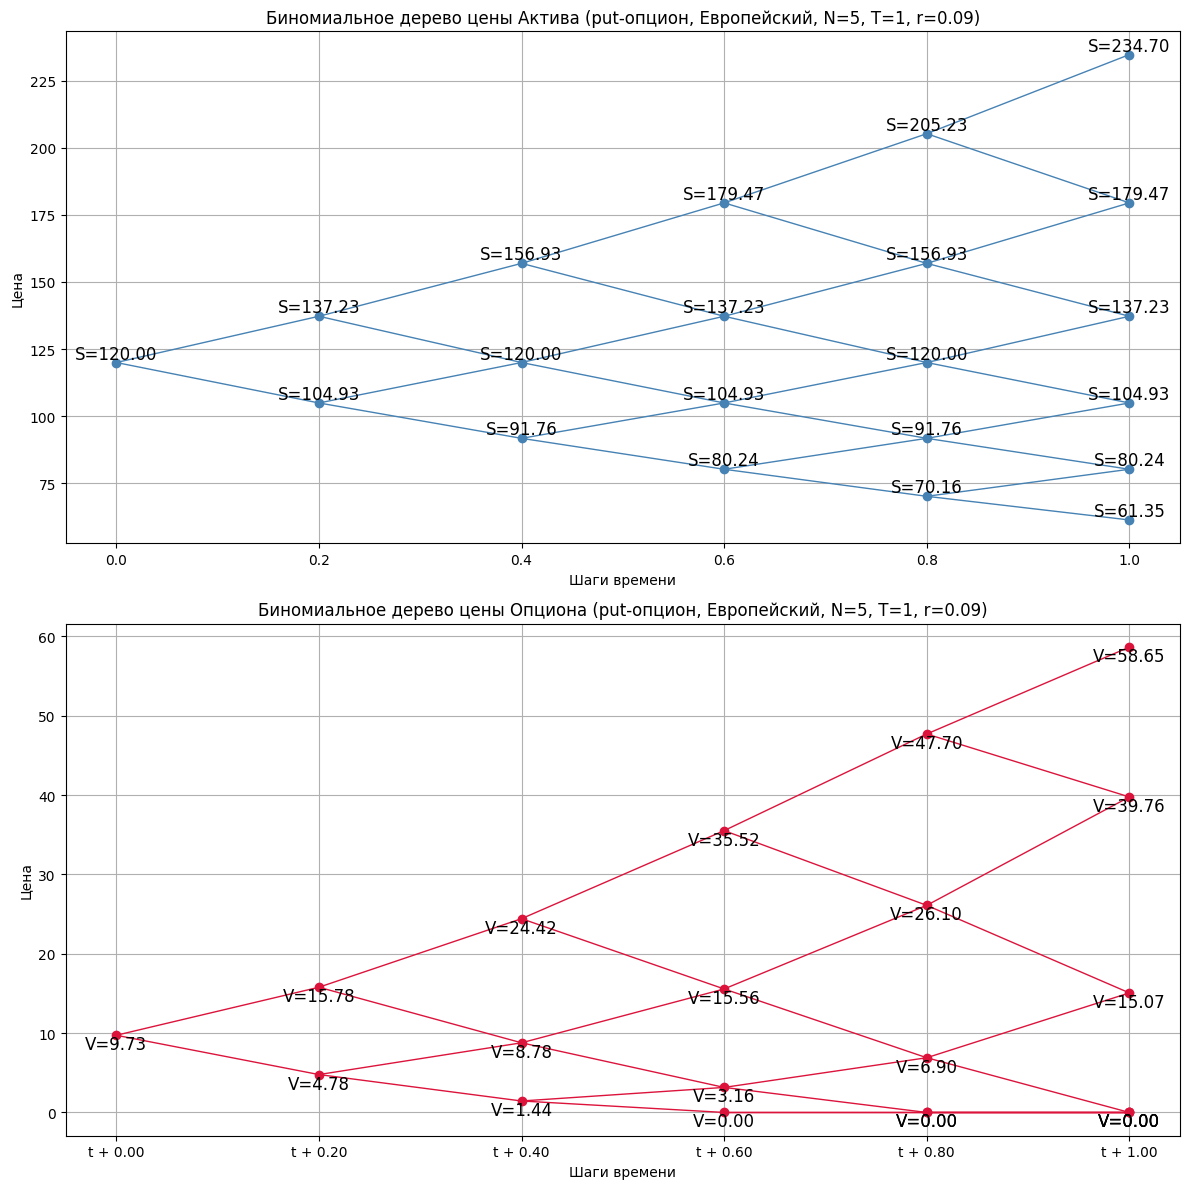

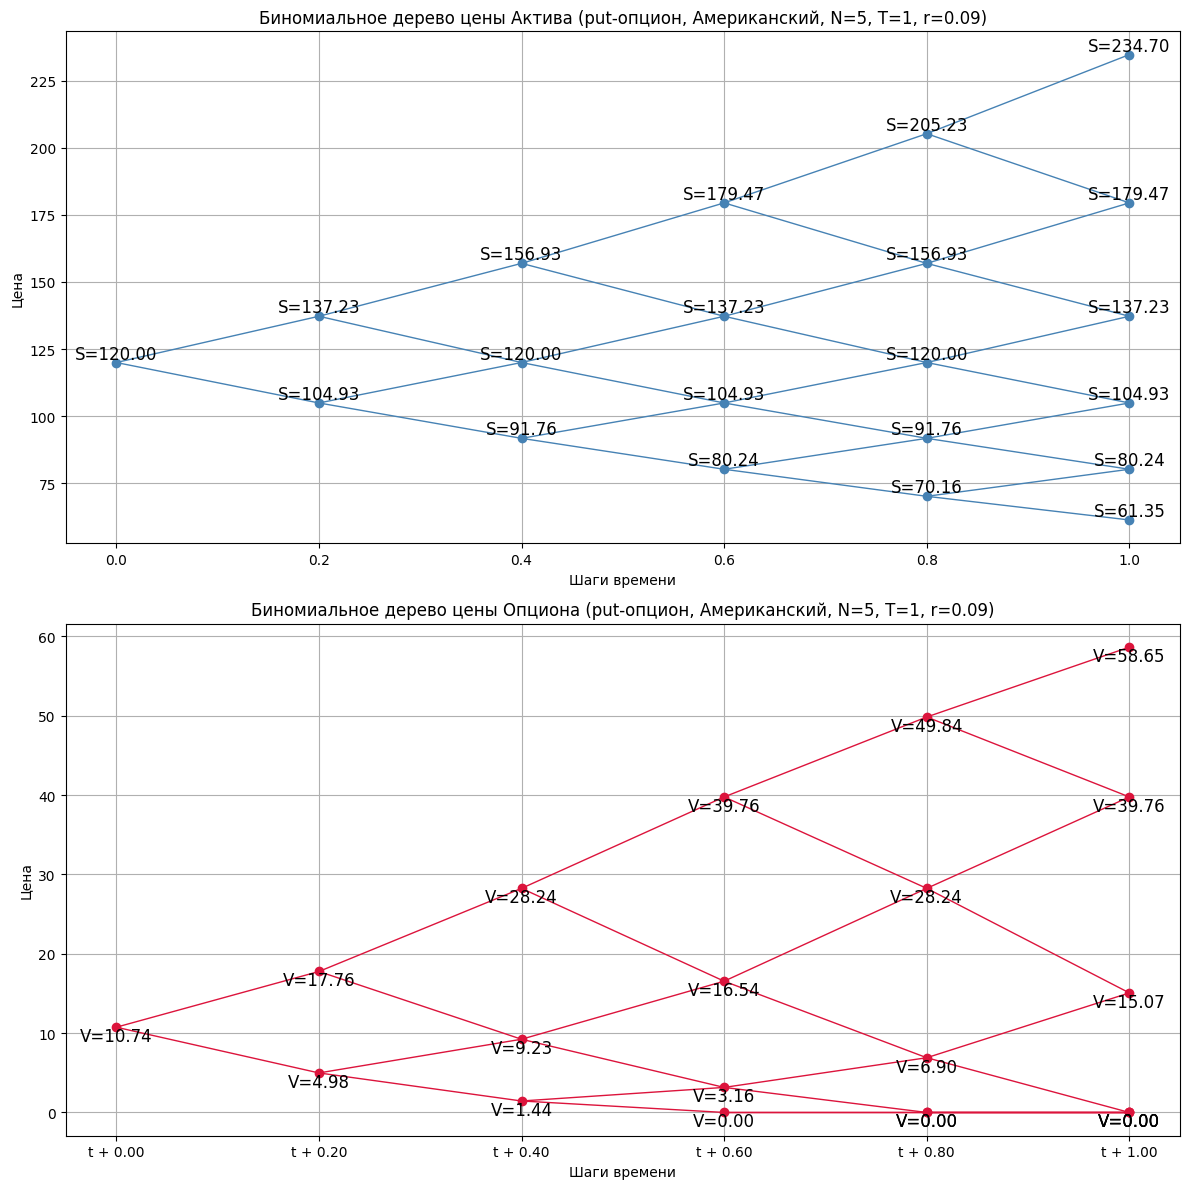

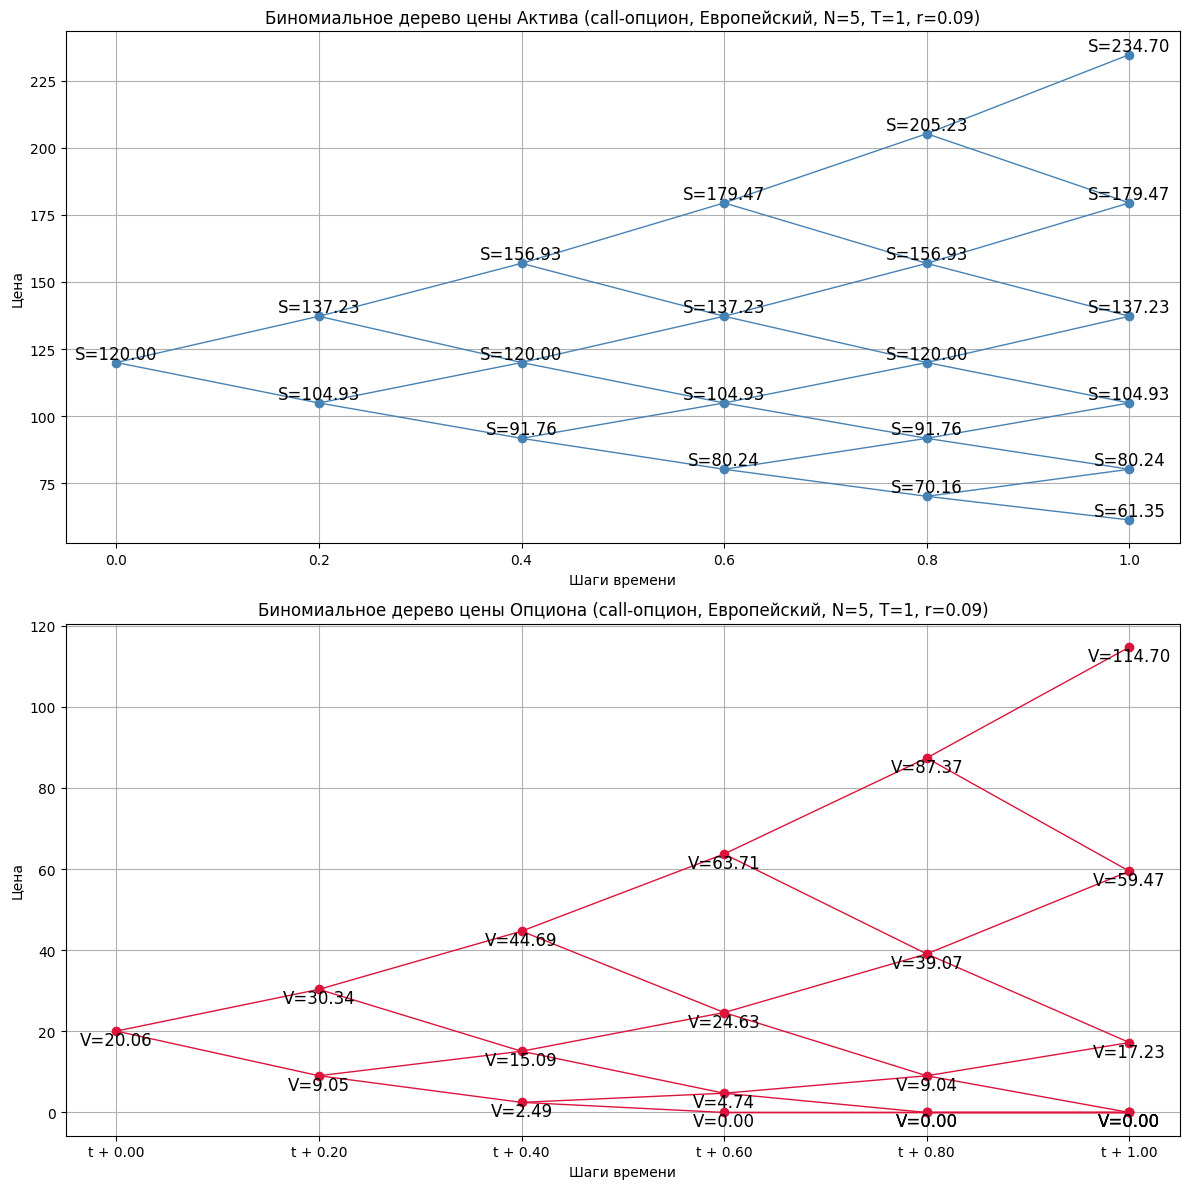

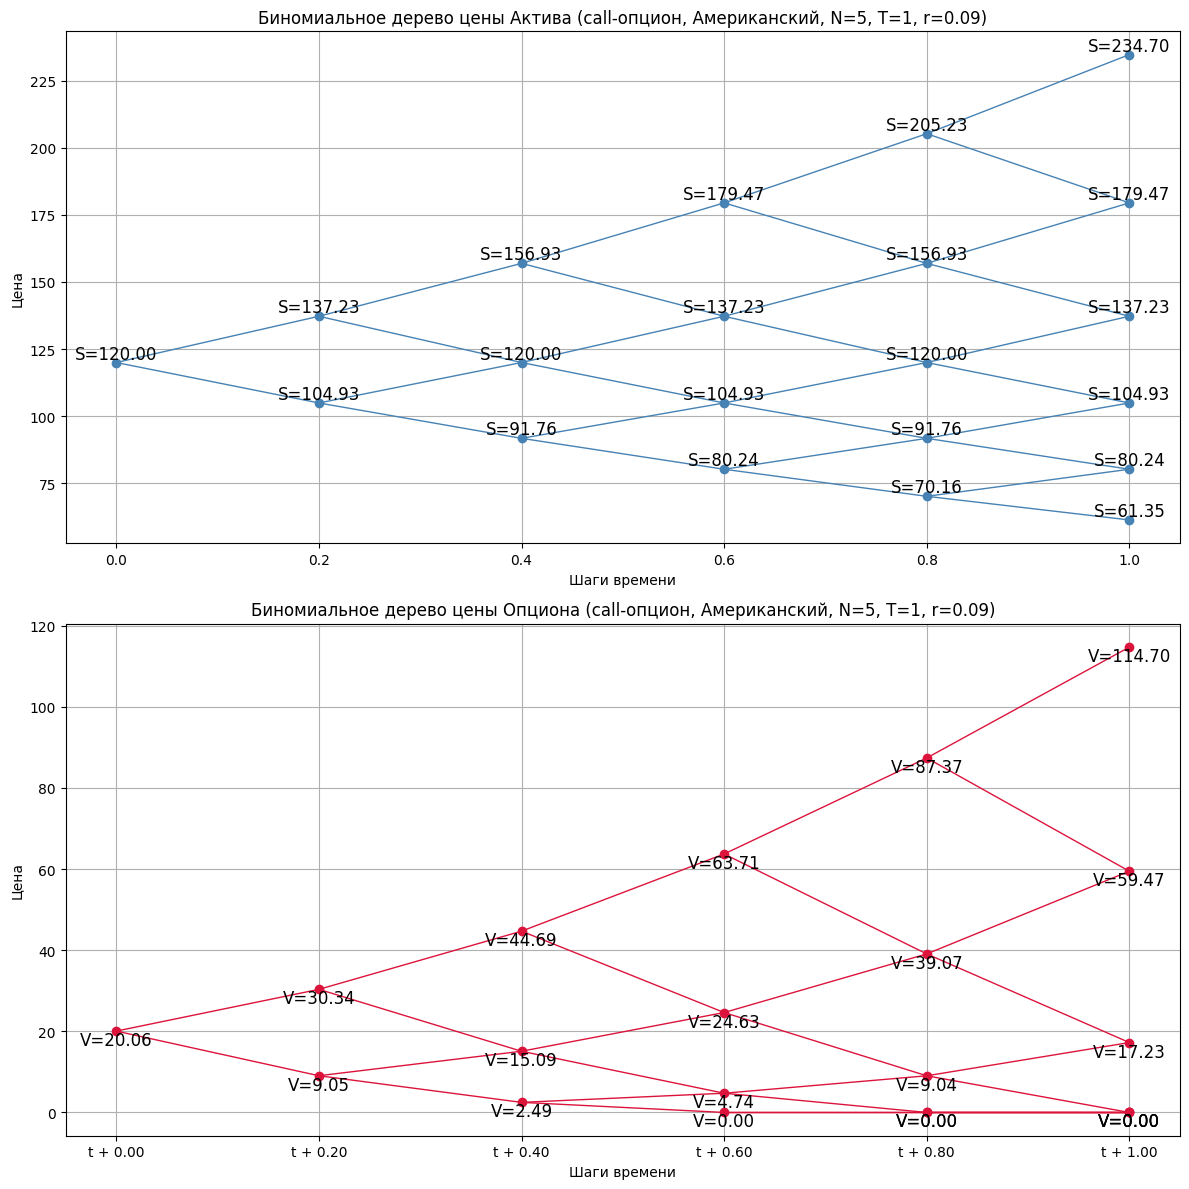

In [30]:
N = 5
prices_euro_put, option_values_euro_put = binomial_tree_options(S, X, T, r, sigma, N, option_type='put', american=False)
plot_binomial_tree(prices_euro_put, option_values_euro_put, T, r, N, 'put', False)

# Американский put-опцион
prices_amer_put, option_values_amer_put = binomial_tree_options(S, X, T, r, sigma, N, option_type='put', american=True)
plot_binomial_tree(prices_amer_put, option_values_amer_put, T, r, N, 'put', True)

# Европейский call-опцион
prices_euro_call, option_values_euro_call = binomial_tree_options(S, X, T, r, sigma, N, option_type='call', american=False)
plot_binomial_tree(prices_euro_call, option_values_euro_call, T, r, N, 'call', False)

# Американский call-опцион
prices_amer_call, option_values_amer_call = binomial_tree_options(S, X, T, r, sigma, N, option_type='call', american=True)
plot_binomial_tree(prices_amer_call, option_values_amer_call, T, r, N, 'call', True)

In [58]:
N_values = range(20, 401)
X = 120
european_put_prices, european_call_prices = [], []
for N in N_values:
    _, option_values = binomial_tree_options(S, X, T, r, sigma, N, option_type='put', american=False)
    _, option_values_call = binomial_tree_options(S, X, T, r, sigma, N, option_type='call', american=False)
    european_call_prices.append(option_values_call[0, 0])
    european_put_prices.append(option_values[0, 0])

In [59]:
bs_price_put = black_scholes_put(S, X, T, r, sigma)
bs_price_call = black_scholes_call(S, X, T, r, sigma)

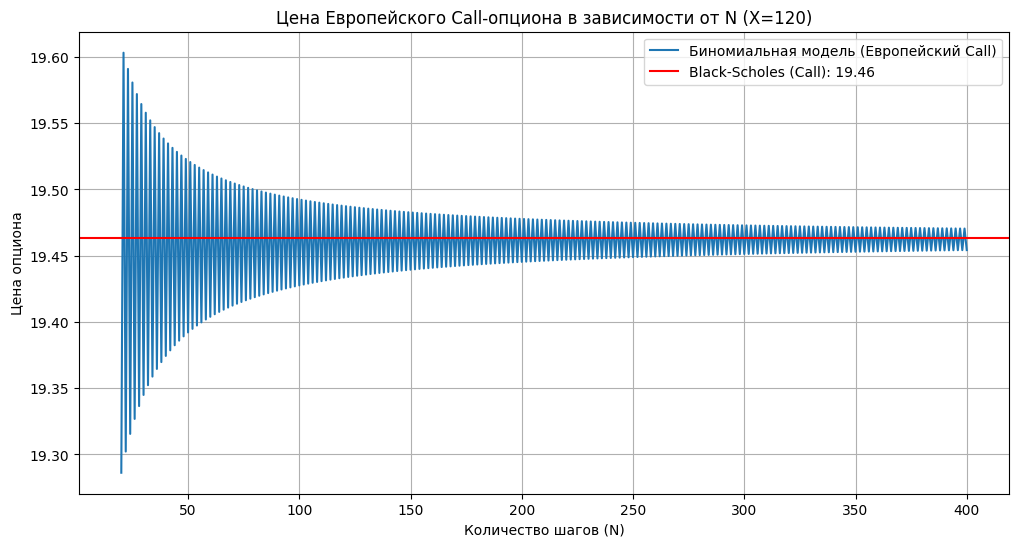

In [60]:
plt.figure(figsize=(12, 6))
plt.plot(N_values, european_call_prices, label='Биномиальная модель (Европейский Call)')
plt.axhline(y=bs_price_call, color='r', linestyle='-', label=f'Black-Scholes (Call): {bs_price_call:.2f}')
plt.xlabel('Количество шагов (N)')
plt.ylabel('Цена опциона')
plt.title('Цена Европейского Call-опциона в зависимости от N (X=120)')
plt.legend()
plt.grid(True)
plt.show()

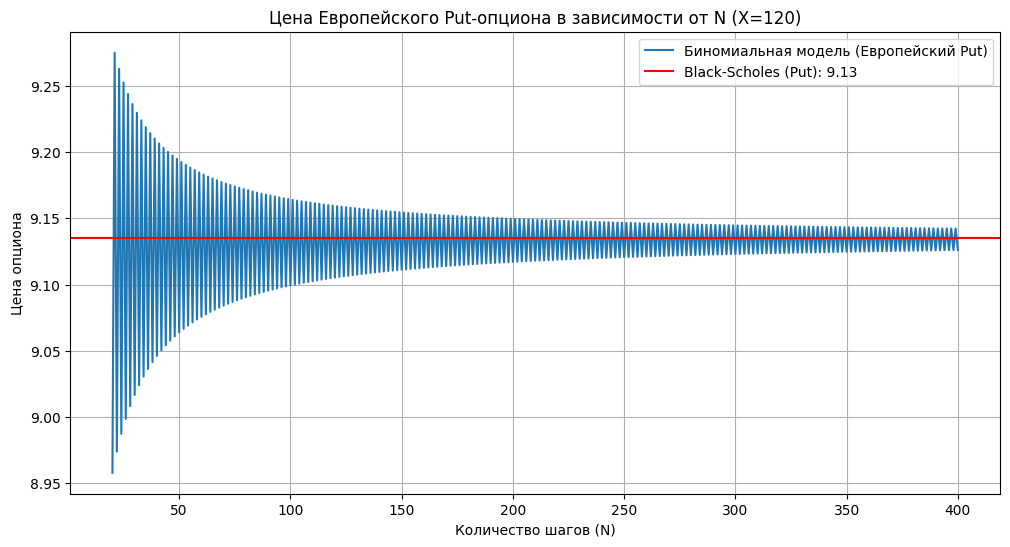

In [61]:
plt.figure(figsize=(12, 6))
plt.plot(N_values, european_put_prices, label='Биномиальная модель (Европейский Put)')
plt.axhline(y=bs_price_put, color='r', linestyle='-', label=f'Black-Scholes (Put): {bs_price_put:.2f}')
plt.xlabel('Количество шагов (N)')
plt.ylabel('Цена опциона')
plt.title('Цена Европейского Put-опциона в зависимости от N (X=120)')
plt.legend()
plt.grid(True)
plt.show()

In [41]:
from py_vollib.black_scholes import black_scholes
def barone_adesi_whaley(S, X, T, r, sigma, option_type='put'):
    """Приближение Barone-Adesi and Whaley для американского put-опциона."""
    flag = 'p' if option_type.lower() == 'put' else 'c'
    return black_scholes(flag, S, X, T, r, sigma)

In [42]:
american_put_prices = []
for N in N_values:
    _, option_values = binomial_tree_options(S, X, T, r, sigma, N, option_type='put', american=True)
    american_put_prices.append(option_values[0, 0])

baw_price_put = barone_adesi_whaley(S, X, T, r, sigma, option_type='put')

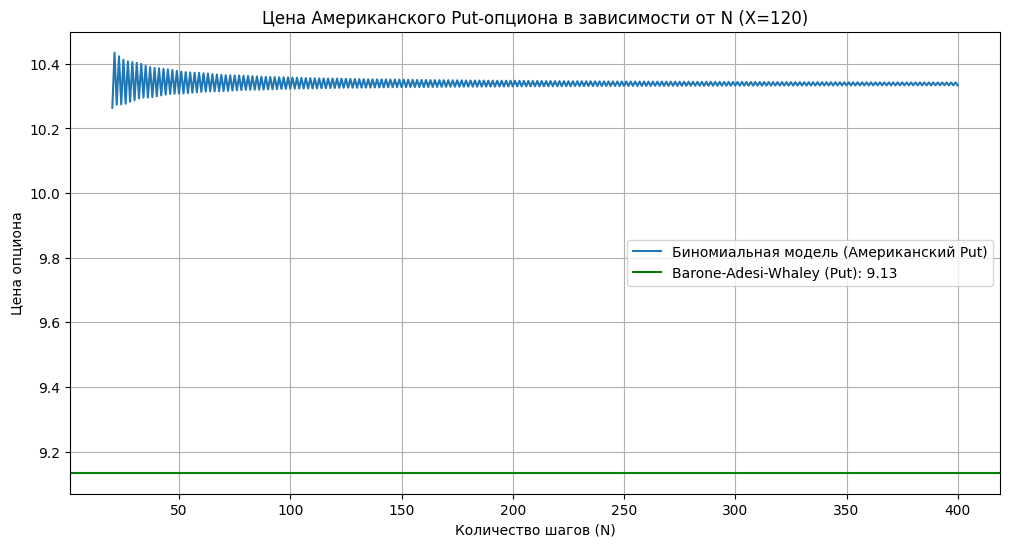

In [43]:
baw_price_put = barone_adesi_whaley(S, X, T, r, sigma, option_type='put')

plt.figure(figsize=(12, 6))
plt.plot(N_values, american_put_prices, label='Биномиальная модель (Американский Put)')
plt.axhline(y=baw_price_put, color='g', linestyle='-', label=f'Barone-Adesi-Whaley (Put): {baw_price_put:.2f}')
plt.xlabel('Количество шагов (N)')
plt.ylabel('Цена опциона')
plt.title('Цена Американского Put-опциона в зависимости от N (X=120)')
plt.legend()
plt.grid(True)
plt.show()

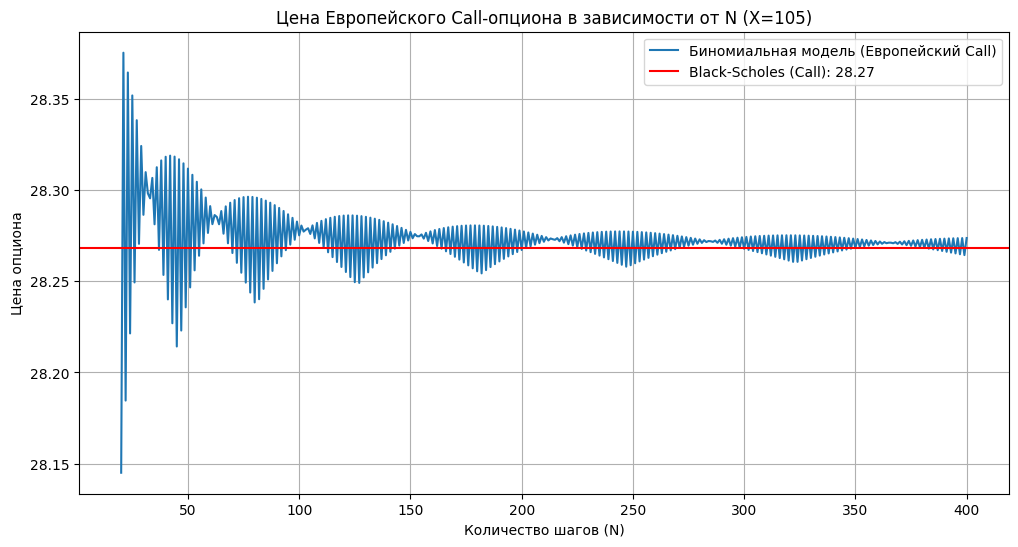

In [62]:
X = 105  
european_call_prices = []
for N in N_values:
    _, option_values = binomial_tree_options(S, X, T, r, sigma, N, option_type='call', american=False)
    european_call_prices.append(option_values[0, 0])

bs_price_call = black_scholes_call(S, X, T, r, sigma)

plt.figure(figsize=(12, 6))
plt.plot(N_values, european_call_prices, label='Биномиальная модель (Европейский Call)')
plt.axhline(y=bs_price_call, color='r', linestyle='-', label=f'Black-Scholes (Call): {bs_price_call:.2f}')
plt.xlabel('Количество шагов (N)')
plt.ylabel('Цена опциона')
plt.title('Цена Европейского Call-опциона в зависимости от N (X=105)')
plt.legend()
plt.grid(True)
plt.show()

In [63]:
def delta_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return norm.cdf(d1)

def gamma(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

In [64]:
call_deltas = [delta_call(S, x, T, r, sigma) for x in range(50, 151)]
gammas = [gamma(S, x, T, r, sigma) for x in range(50, 151)]

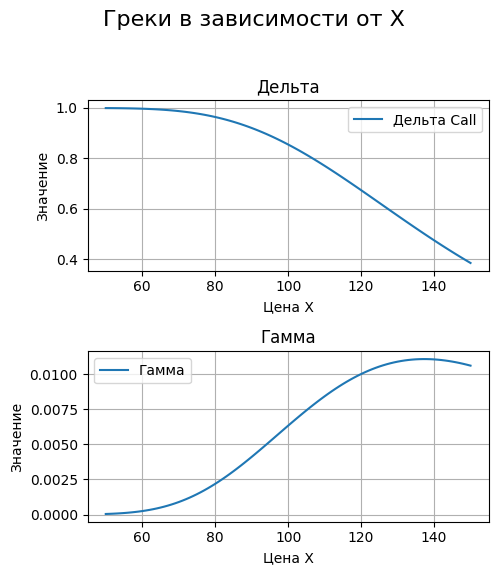

In [74]:
fig, axs = plt.subplots(2, 1, figsize=(5, 6))
axs = axs.flatten()  

# Delta
axs[0].plot(range(50, 151), call_deltas, label='Дельта Call')
axs[0].set_xlabel('Цена X')
axs[0].set_ylabel('Значение')
axs[0].set_title('Дельта')
axs[0].legend()
axs[0].grid(True)

# Gamma
axs[1].plot(range(50, 151), gammas, label='Гамма')
axs[1].set_xlabel('Цена X')
axs[1].set_ylabel('Значение')
axs[1].set_title('Гамма')
axs[1].legend()
axs[1].grid(True)

fig.suptitle('Греки в зависимости от X', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])  
plt.show()

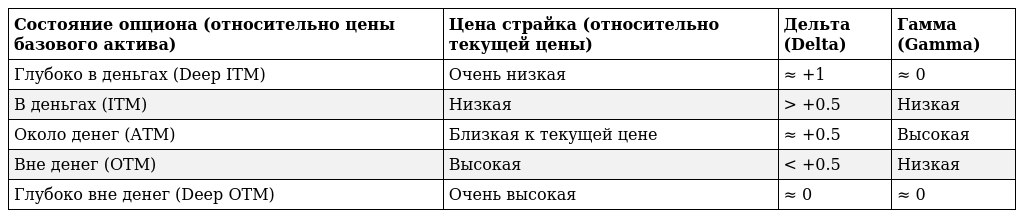

Когда вы повышаете цену страйка (strike price), опцион становится глубоко "вне денег". 

В таком случае, вероятность исполнения опциона резко снижается, и его стоимость становится менее чувствительной к небольшим изменениям параметров модели.